# 问题四：技术演进中介分解与能力前沿预测

全部计算数据使用本地附件；核心假设为控制可比规模后，剩余时间效应代表非规模技术进步。历史归因以完整N/D基础模型为主；大样本榜单分类型预测单独报告，时间轴不混用。

从头执行本notebook会重新生成审计、贡献、桥接、前沿、回测、图件和两篇章节。前面三问代码与结果只读。JSON原件不删除或修补，损坏与替代规则有逐文件台账。

In [1]:
from pathlib import Path
import sys,time,json
import pandas as pd
from IPython.display import display,Markdown,Image
ROOT=Path.cwd()
if not (ROOT/'real_attachments').exists(): ROOT=ROOT.parent
assert (ROOT/'Q4/evolution_model.py').exists()
sys.path.insert(0,str(ROOT/'Q4'))
from data_pipeline import OUT,read_data,aggregate_c8
from evolution_model import mediation_analysis,bridge_analysis,coupled_forecast,broad_analysis
from run_analysis import provenance
started=time.time()
print('Python:',sys.executable)
print('计算数据：仅本地附件；预测起点由最后可比观测日期决定。')

Python: /Users/luochen/华为杯/F题/z备份_副本/.repro-env/bin/python
计算数据：仅本地附件；预测起点由最后可比观测日期决定。


## 一、模型建立与推导

下文给出变量、假设、噪声、有限时期反事实分解、预算耦合和验证方法。结果由后续代码真实运行后产生。

In [2]:
display(Markdown((ROOT/'Q4/模型建立.md').read_text(encoding='utf-8')))

# 问题四：技术演进的结构中介模型与受算力约束的能力前沿

## 4.1 研究对象与证据结构

本问区分两个统计目标。历史归因回答：在可比较的基础模型中，能力变化有多少经参数量和训练数据量传递，有多少由规模之外的时间路径解释。前沿预测回答：以最后可比评测日期为起点，算力增速放缓时，未来12个月和24个月的领先能力处于何种条件范围。两者不共用一个未经筛选的混合总体。

全部计算数据来自本地附件。C1为模型级能力与类型的来源，C3用于来源分层、年份覆盖和同源分数核对，C4提供发布日期、参数、训练数据量、算力及权重开放信息，C5/C6承担Loss—Benchmark桥接，C8用于逐任务重建。前面三问通过已保存接口和问题三求解器进入第四问，不重新拟合或改变其结果。外部文献仅解释方法，不提供新增观测。

### 4.1.1 能力指标与开源口径

令模型$i$的六个归一化任务得分为$s_{ik}$，以固定等权定义综合能力
$$
S_i=\frac16\sum_{k=1}^{6}s_{ik},\qquad
Z_i=\operatorname{logit}(S_i/100).
$$
六任务依次为IFEval、BBH、MATH Lvl 5、GPQA、MuSR和MMLU-PRO。计算logit时仅将比例裁到$[0.001,0.999]$，防止无穷大；不改变原始分数。等权保持排行榜定义，删除单项任务后的重估检验指标选择的影响。分数是六任务代理能力，不能解释为所有任务的通用智能水平。

“开源”在本问操作化为开放权重、许可证明确允许至少研究使用的模型集合，不声称所有入选许可证都满足OSI开源定义。C1采用代码中显式的许可证允许列表，缺失、unknown和other默认不纳入。完整训练元数据样本还要求C4的`Open model weights?=Yes`。这只是附件声明层面的筛选，不是逐个仓库在线验证。基础模型、对话／微调模型、合并模型、继续预训练模型分别标记；后三者不能因名称相似而被当作独立基础训练实验。

同一仓库模型重复记录取最早有效提交，不把重复评测当作新模型。历史归因只对C1中标为pretrained、C4未标注底模、非明显MoE且$N,D$齐全的模型开展。对话／微调模型常只有后训练数据量，因此不能直接把它填入总预训练$D$。

### 4.1.2 匹配、时间与缺失信息

模型名称匹配采用确定性的规范化键，保留数字间的小数点，防止OPT-1.3B与OPT-13B碰撞。候选必须唯一、参数数量级一致、发布命名空间与元数据组织能够核对；歧义、无法确认的重上传均保留在匹配台账，不能以得分相近为匹配依据。完整样本的$N$采用与$D$配套的C4训练元数据定义，同时保留排行榜参数量用于审计。不补造缺失的训练Token数。

完整$N,D$历史模型使用发布日期，以年为单位并相对固定参考日期中心化。大样本榜单分析使用提交日期。两条时间轴分别建表、估计、解释，不用发布日期补全一部分提交日期后拼成单轴。C3中的历史文献来源与排行榜来源分别汇总；无法确认相同评测标准的早期历史分数不进入能力趋势回归。

元数据为事后收集的快照。按发布日期划分的验证是回溯性发布队列检验，不是复原每个历史时点实际已知的信息集；大样本提交日期回测也不能证明元数据具有完全一致的历史版本。

### 4.1.3 截断JSON与逐任务聚合

C8的每个JSON先做完整解析检查，记录文件哈希、错误和目录。原始文件不修改、不补括号。每个目录选择文件名时间戳最新且可解析的评测；若不存在，目录仅退出逐任务分析，其C1有效记录不因此自动删除。能解析但缺失所需任务的记录也不能补零。

选择MuSR的谋杀推理、物体放置和团队分配三个叶子任务，读取`acc_norm,none`，分别使用随机猜测基线$1/2,1/5,1/3$。单项重建为
$$
\widetilde s_{ij}=100\max\left(0,\frac{a_{ij}-b_j}{1-b_j}\right),
\qquad S_i^{\mathrm{MuSR}}=\frac13\sum_{j=1}^{3}\widetilde s_{ij}.
$$
只有三项齐全才产生聚合值；同时按模型类型汇总各叶子任务。重建值与C1快照对照，但不直接覆盖C1，因为最新评测记录可能采用不同版本。`acc_norm`是评测器的选项长度归一化准确率，不等于已经扣除了随机猜测基线。

## 4.2 因果结构与随机扰动

本研究采用用户确认的关键假设：在模型规模和评测口径可比的条件下，剩余时间路径代表架构、优化、数据工程等非规模技术进步。时间本身不是可操作的技术干预，故这是一个时代变化的结构解释，不是随机试验证实的机制。

因果图的主干为$T\rightarrow(\ln N,\ln D)\rightarrow Z\rightarrow S$，另有$T\rightarrow Z$。前者为规模中介路径，后者为非规模路径。发布机构资源等未观测变量可能同时影响规模与能力，作为偏离主假设的敏感性情形处理。噪声分别进入规模和能力方程，不向观测表随机加数。

令$M_i=(\ln N_i,\ln D_i)^\top$，中介方程为
$$
M_i=a_0+a_TT_i+\varepsilon_{Mi},\qquad
\mathbb E(\varepsilon_{Mi}\mid T_i)=0,
\quad\operatorname{Cov}(\varepsilon_{Mi})=\Sigma_M.
$$
两个规模扰动可以相关：同一模型的参数和数据投资具有共同来源。主模型假定规模扰动与能力扰动独立，并保持跨时期残差分布稳定。潜在结果解释还要求不存在未处理的时间—规模—能力混杂、干扰和严重选择偏差，且相关规模范围有足够重叠。机构重抽样能反映组内相关导致的估计不确定性，不能自动消除机构混杂。

## 4.3 承接标度律的能力响应

### 4.3.1 结构约束与可解释性

沿用问题二接口中的$A,B,\alpha,\nu$和十亿单位，构造可约损失及规模指数
$$
r(N,D)=AN^{-\alpha}+BD^{-\nu},\qquad
x(N,D)=-\ln r(N,D).
$$
能力方程为
$$
Z_i=\beta_0+\kappa x(N_i,D_i)+\gamma T_i+\varepsilon_{Yi}.
$$
该结构把前两问已确定的规模收益形状带入第四问，但$\beta_0,\kappa,\gamma$重新由附件C估计。它避免在小样本中同时重新识别两套幂指数，代价是必须接受标度形状跨模型族迁移的工作假设。主模型不再单独解释$Q$和$p$的历史贡献：它们缺少历史模型级观测，属于非规模时间项所代理的因素。

作为结构敏感性，另拟合
$$
Z_i=\beta_0+\beta_N\ln N_i+\beta_D\ln D_i+\gamma T_i+\varepsilon_{Yi},
$$
同时设置仅规模和仅时间两个简化对照。比较采用同一数据划分和同一能力分误差，不能把不同样本的得分直接排列。

### 4.3.2 局部传导关系

令$w_N=AN^{-\alpha}/r$、$w_D=BD^{-\nu}/r$，则$w_N+w_D=1$，有
$$
\frac{\partial Z}{\partial\ln N}=\kappa\alpha w_N,
\qquad\frac{\partial Z}{\partial\ln D}=\kappa\nu w_D.
$$
由中介方程，局部时间趋势分解为
$$
\frac{\mathrm d Z}{\mathrm dT}
=\underbrace{\kappa(\alpha w_Na_{T,N}+\nu w_Da_{T,D})}_{\text{经规模传递}}
+\underbrace{\gamma}_{\text{非规模路径}}.
$$
能力分尺度上的导数还要乘$S(1-S/100)$。因此不能直接把两个logit回归系数相除解释为能力分贡献；非线性条件下需要反事实计算。

### 4.3.3 参数估计与经验噪声积分

令 $X_M$的第 $i$行为 $(1,T_i)$，$M$的第 $i$行为 $(\ln N_i,\ln D_i)$；$X_Y$的第 $i$行为 $(1,x(N_i,D_i),T_i)$。中介和能力方程分别采用最小二乘：

$$
\widehat A=\arg\min_A\|M-X_MA\|_F^2=X_M^+M,\qquad
\widehat b=\arg\min_b\|Z-X_Yb\|_2^2=X_Y^+Z.
$$

$X^+$为Moore–Penrose广义逆，$\|\cdot\|_F$为所有矩阵元素平方和开根号；代码使用最小二乘分解而非显式求逆，并记录秩及条件数。残差为 $\widehat e_{M,i}=M_i-(1,T_i)\widehat A$、$\widehat e_{Y,i}=Z_i-X_{Y,i}\widehat b$，中介残差的两个分量成对保留。普通能力点预测在分数尺度积分：

$$
\widehat S(x,t)=\frac1n\sum_{b=1}^n100\operatorname{expit}(\widehat\beta_0+\widehat\kappa x+\widehat\gamma t+\widehat e_{Y,b}),\qquad
\operatorname{expit}(z)=\frac1{1+e^{-z}}.
$$

这里 $Z=\ln[p/(1-p)]$、$p=\operatorname{clip}(S/100,0.001,0.999)$是logit变换。第四问的 $Z$为能力变换，不是第一问的指标正态分数矩阵。


## 4.4 有限时期的贡献推导

在完整样本的发布日期四分位区间选定$t_0,t_1$，以减少端点支持不足。令
$$
G(t,t')=\mathbb E_{\varepsilon_M,\varepsilon_Y}
\left[100\operatorname{expit}\left\{\beta_0+
\kappa x\big(\exp(a_0+a_Tt'+\varepsilon_M)\big)+\gamma t+\varepsilon_Y\right\}\right].
$$
外层$t$控制非规模时间路径，内层$t'$控制规模中介的时代状态。中介扰动按模型成对保留，能力扰动按独立残差分布积分。在实际计算中，采用两组经验残差的笛卡尔积平均，保留$N,D$噪声相关性并实现主模型的跨方程独立假设。这同时避免忽略非线性变换的Jensen偏差。

令 $m_a(t')=(1,t')\widehat A+\widehat e_{M,a}$，实际使用的经验积分为
$$
\widehat G(t,t')=\frac1{n^2}\sum_{a=1}^n\sum_{b=1}^n100\operatorname{expit}\{\widehat\beta_0+\widehat\kappa x(e^{m_{a,N}(t')},e^{m_{a,D}(t')})+\widehat\gamma t+\widehat e_{Y,b}\}.
$$
$n$为当前拟合样本数；重采样时使用当次样本的残差和样本数。总变化绝对值不超过 $10^{-6}$分时，代码将贡献占比设为缺失，而非除以近零总量。

规模贡献与非规模贡献定义为两种路径切换顺序的平均：
$$
\Delta_S=\frac12\{G(t_0,t_1)-G(t_0,t_0)+G(t_1,t_1)-G(t_1,t_0)\},
$$
$$
\Delta_T=\frac12\{G(t_1,t_0)-G(t_0,t_0)+G(t_1,t_1)-G(t_0,t_1)\}.
$$
将两式相加，中间两项成对抵消，得到
$$
\Delta_S+\Delta_T=G(t_1,t_1)-G(t_0,t_0)=\Delta_{\mathrm{total}}.
$$
因此该对称分解在能力分尺度严格可加，避免人为指定先扩大规模还是先改进技术。当总变化明显不为零时，贡献占比分别为$\Delta_S/\Delta_{\mathrm{total}}$和$\Delta_T/\Delta_{\mathrm{total}}$。负份额或超过100%的份额表示路径相互抵消，不强制裁剪。

不确定性采用固定种子、按发布机构整组重抽样的400次bootstrap：每次重估中介和能力方程，再在原始固定时间区间重新计算贡献。区间为经验2.5%和97.5%分位，条件于问题二参数及样本选择机制。

## 4.5 验证与未观测混杂敏感性

机构留出验证考察跨机构泛化；发布日期阻塞留出考察从较早发布队列预测较晚发布队列。点预测对能力残差积分后计算MAE、RMSE和偏差。另以90%分位模型检查覆盖率和logit尺度的分位损失，不能把均值预测的误差当作前沿的全部验证。

对未观测混杂，在缩减尺度方程$x=a_x+b_xT+v$中令$v$与能力结构扰动相关系数为$\rho$。在线性残差近似下，对规模系数施加偏差修正
$$
\kappa(\rho)=\widehat\kappa-
\frac{\rho}{\sqrt{1-\rho^2}}\frac{s_Y}{s_x},
\quad
\gamma(\rho)=\widehat\gamma+
\big[\widehat\kappa-\kappa(\rho)\big]b_x,
$$
并相应调整截距。取$\rho\in[-0.6,0.6]$重算贡献。这是保持经验能力噪声分布不变的系数偏差压力测试，不是对真实混杂强度的估计，也不是一般非线性中介模型的精确识别定理。另将$D$统一或仅对较晚模型乘以$0.5,1,2$，检查元数据尺度误差和时变测量偏差的影响。

## 4.6 Loss—Benchmark分层桥接

C6按`Loss_Comparability`划分高可比与中可比层，C5用于检查重叠记录的一致性。每层独立估计非增的等渗函数
$$
\widehat f_\ell=\arg\min_{f\,\mathrm{nonincreasing}}
\sum_{i\in\mathcal I_\ell}(S_i-f(L_i))^2.
$$
等渗回归＝在损失越低、能力不下降的约束下拟合最小二乘分段函数。仅在该层实测损失最小值与最大值之间换算；超出范围返回缺失，不能把输入裁到边界后伪称预测。设层 $\ell$ 的支撑区间为 $[L_{\ell,min},L_{\ell,max}]$，则报告换算值
$$
\widehat S_\ell(L)=\begin{cases}\widehat f_\ell(L),&L_{\ell,min}\le L\le L_{\ell,max},\\\mathrm{NA},&\text{其他}.\end{cases}
$$
留一验证只有训练折支撑区间内的测试点计入误差，并同时报告总点数与可验证点数。中可比层进一步按报告来源整组留出，避免同一报告的近似Loss重复记录被当作独立验证。

高可比层提供同验证集桥接，中可比层只是跨报告情景。二者都不能自动将基础模型的预训练Loss等同于经后训练的聊天能力。问题二到问题四的结构响应是另一个带标度迁移假设的模型，必须与这些直接桥接结果并列比较，不能以结构模型的预测取代桥接证据。

## 4.7 算力放缓下的前沿预测

### 4.7.1 算力路径

预测起点$t_\star$为C1最后有效提交日期。C4仅使用该日及以前发布、权重开放、具有正训练算力、未标注底模、非明显MoE、非Speculative且任务涉及语言建模／代码生成／对话的模型；这仍依赖附件元数据分类。按季度计算训练算力90%分位，拟合其对数时间趋势$g_C$；最近一年算力90%分位作为$C_\star$。
$$
C_h=C_\star\exp\{r_C\max(g_C,0)h/12\},
\quad r_C\in\{0,1/4,1/2\}.
$$
冻结、历史增速四分之一与二分之一分别构成放缓情景，主情景为四分之一。它们是明确假设，不是附件提供的真实未来预算。

### 4.7.2 承接问题三的资源前沿

使用问题三的$p_0$、最高50%文档质量参考切片、$s_Q=1$、4096上下文和指数成本作为展示主情景，求得每个$C_h$下的$(N_h^*,D_h^*,Q_h^*,L_h^*)$。它继承问题一质量评价、问题二共同修正标度律和问题三优化约束，不新建不一致的成本公式。其他质量与三类成本场景单独核对资源和损失敏感性。

在完整$N,D$样本上估计条件90%分位响应
$$
q_{0.9}(Z\mid x,T)=b_{0,0.9}+\kappa_{0.9}x+\gamma_{0.9}T,
\qquad\kappa_{0.9}\ge0.
$$
使用分位损失$\rho_\tau(u)=u(\tau-\mathbf1_{u<0})$构成线性规划求解。规模系数非负是前沿模型的单调约束，不用于强制历史中介贡献为正。


令设计行 $X_i=(1,x_i,T_i)$，分位水平 $\tau=0.9$，残差拆为 $r_i^+-r_i^-$。上述估计实际求解线性规划

$$
\min_{b,r^+,r^-}\ \tau\sum_i r_i^++(1-\tau)\sum_i r_i^-,\qquad
Xb+r^+-r^-=Z,\quad r_i^+,r_i^-\ge0,\quad b_{scale}\ge0.
$$

截距和时间系数不受非负约束。检验集 $\mathcal V$上的前沿覆盖率与分位损失分别为

$$
\widehat{\mathrm{Coverage}}=\frac1{|\mathcal V|}\sum_{i\in\mathcal V}\mathbf1\{Z_i\le X_i\widehat b\},\qquad
\widehat{\mathrm{Pinball}}=\frac1{|\mathcal V|}\sum_{i\in\mathcal V}\rho_{0.9}(Z_i-X_i\widehat b).
$$

名义90%条件分位和预测估计的95%重采样区间不是同一个量。对每个机构与元数据重采样产生的预测 $F_h^{(b)}$，区间端点为 $[\operatorname{Quantile}_{.025}\{F_h^{(b)}\},\operatorname{Quantile}_{.975}\{F_h^{(b)}\}]$；该区间保持问题二参数固定，不含所有结构误差。

为避免短期趋势无限延伸，设技术趋势按半衰期$H$衰减，$\delta=12\ln2/H$，则$h$个月内有效技术推进年数为
$$
\psi_H(h)=\frac{1-\exp(-\delta h/12)}{\delta},
\qquad \psi_\infty(h)=h/12.
$$
主取$H=24$个月，另以12个月和不衰减作敏感性；该半衰期并未由短榜单识别。主资源路径在质量上限保持有效时，$Q,p$固定，因此共同质量乘子在可约损失比值中抵消。预测为
$$
F_h=100\operatorname{expit}\left[
z_\star-\kappa_{0.9}\ln\frac{L_h^*-E}{L_0^*-E}
+\gamma_{0.9}\psi_H(h)\right],
$$
其中$z_\star=b_{0,0.9}+\kappa_{0.9}x(N_0^*,D_0^*)+\gamma_{0.9}t_\star$。这定义了资源最优路径上的基础模型条件90%分位能力，属于可操作的统计前沿，不是绝对最高分保证。$\kappa_{0.9}\ge0$时，固定技术状态与质量乘子，最小化Loss也最大化这一能力响应。

质量改进不在基准截距之外重复加一次：前沿只使用相对Loss变化，时间项代表未单独建模的整体非规模演进。绝对C6桥接另外报告，不再叠加同一时间收益。未来$N,D$超出完整样本范围时逐项标注，不隐藏外推。

预测区间结合完整能力样本的机构bootstrap和C4算力元数据的机构bootstrap，重估能力系数、起点预算与算力趋势；快速资源计算须与完整问题三求解器在预算覆盖范围内比较。该区间不包含未识别的质量尺度、跨验证集系统偏差或所有外推结构误差，成本／质量场景和技术半衰期另行展示，不能揉成没有含义的单个“置信区间”。

### 4.7.3 大样本分类型前沿对照

对基础、对话／微调与合并模型分别拟合$Z=b_0+b_N\ln N+b_TT+e$的分位模型，$D$缺失不补造；故$b_T$仅是描述性时间变化，不能替代完整中介模型的非规模贡献。以最近三个月的参数分布为参考，按$\nu/(\alpha+\nu)$将算力对数增量转换为参数规模增量，再与训练期残差分布组合，取预测能力分布的90%分位。使用固定的101点中点分位网格积分，避免把“条件90%分位在参数90%分位处的值”误认为总体90%分位。


具体地，设 $q_m=(m-1/2)/101$、$m=1,\ldots,101$，令 $n_m$为最近三个月 $\ln N$的 $q_m$分位数，$e_l$为训练期logit残差的 $q_l$分位数。没有最近三个月样本时以全部训练样本作为规模参照。定义

$$
\Delta n_h=\frac{\nu}{\alpha+\nu}r_C\max(g_C,0)\frac h{12},\qquad
S_{ml,h}=100\operatorname{expit}\{b_0+b_N(n_m+\Delta n_h)+b_T[T_\star+\psi_H(h)]+e_l\},
$$
$$
F_h^{broad}=\operatorname{Quantile}_{0.9}\{S_{ml,h}:1\le m,l\le101\}.
$$

$T_\star$在此模型相对2024-06-01，以365.25天为一年；完整训练元数据模型的时间原点为2023-01-01，两者不能互换。残差与规模网格做笛卡尔积，是模型定义的经验分布组合；未宣称由此恢复了未观测训练数据量 $D$。

在逐个历史月截点，仅用此前提交模型和此前发布的算力元数据拟合，预测之后1至3个月的同类型月度90%分位，并与上月90%分位不变的朴素基线比较。样本少于5个的目标月不纳入回测。该验证不能延长为12/24个月的直接实证验证；基础、对话和合并模型分别报告成功与失败。

## 4.8 可复现性与结论边界

全部随机过程固定种子。独立核验包括贡献可加性、同一时间零效应、反向时间符号、关闭路径后的零贡献、规模弹性有限差分、预算守恒、出界桥接缺失、逐任务聚合和原始文件哈希。方法、结果表、图和已运行notebook共享同一入口。数值核验通过说明实现符合公式与输入约定，不说明因果假设已经被证明。

方法参考仅用于定义：[Imai等，因果中介效应的识别与敏感性分析](https://imai.fas.harvard.edu/research/mediation.html)；[Hugging Face，排行榜归一化定义](https://huggingface.co/docs/leaderboards/open_llm_leaderboard/normalization)。本章没有引入这些网站上的额外模型观测。


## 二、样本筛选与确定性匹配

名称匹配保留小数点，限定命名空间与参数数量级，拒绝歧义。不将缺失D补为估计观测，不将对话模型的后训练数据量当成预训练总量。

In [3]:
clean,nd,epoch,paired=read_data()
display(pd.Series(json.loads((OUT/'data_audit.json').read_text(encoding='utf-8')),name='数据审计'))
display(nd[['Model','N','D','publication_date','S']])

c1_rows                                                                 4576
c1_unique_screened                                                      2449
c1_duplicate_removed                                                      57
dates                                               [2024-06-08, 2025-03-13]
types                      {'chat_finetuned': 1542, 'merge': 667, 'pretra...
matched                                                                   69
primary_nd                                                                35
nd_organizations                                                          10
nd_publication_range                                [2021-03-21, 2024-09-24]
c3_rows                                                                 4599
c3_sources                 {'same_leaderboard': 4573, 'historical_noncomp...
score_rebuild_max_error                                                  0.0
Name: 数据审计, dtype: object

,Model,N,D,publication_date,S
0,google/gemma-7b,8.538074,6000.000000,2024-02-21,15.442819
2,EleutherAI/gpt-neox-20b,20.000000,341.173368,2022-02-09,6.116522
3,EleutherAI/pythia-160m,0.160000,299.892736,2023-04-03,5.730395
4,EleutherAI/pythia-410m,0.410000,299.892736,2023-04-03,5.227072
5,Qwen/Qwen2-1.5B,1.500000,7000.000000,2024-06-07,10.445453
6,Qwen/Qwen2-7B,7.000000,7000.000000,2024-06-07,23.925162
7,bigcode/starcoder2-15b,15.000000,913.230000,2024-02-29,12.539175
8,bigcode/starcoder2-3b,3.000000,622.090000,2024-02-29,6.549148
9,bigcode/starcoder2-7b,7.000000,658.580000,2024-02-29,8.293438
10,microsoft/phi-1_5,1.300000,30.000000,2023-09-11,7.170967


## 三、C8截断JSON与逐任务检验

扫描全部文件，保留原件与哈希；同目录选择最新可解析记录。MuSR必须由三个叶子任务分别扣除随机猜测基线后聚合，缺项不补零。

In [4]:
c8,c8audit=aggregate_c8(clean)
display(pd.Series(c8audit,name='逐任务审计'))
display(pd.read_csv(OUT/'tables/c8_corrupt_files.csv'))
display(pd.read_csv(OUT/'tables/c8_task_type_summary.csv'))

json_files                                                                        1958
corrupt_files                                                                        4
directories                                                                       1863
directories_without_valid                                                            3
corrupt_directories_with_fallback                                                    1
models                                                                            1860
complete                                                                          1856
matched                                                                           1012
matching_within_1e_6                                                               967
median_abs_difference                                                              0.0
p95_abs_difference                                                                 0.0
note                                 latest

,file,error
0,real_attachments/C_efficiency_evolution/detail...,Unterminated string starting at: line 1453 col...
1,real_attachments/C_efficiency_evolution/detail...,Unterminated string starting at: line 1162 col...
2,real_attachments/C_efficiency_evolution/detail...,Unterminated string starting at: line 1194 col...
3,real_attachments/C_efficiency_evolution/detail...,Expecting property name enclosed in double quo...


,type,task,count,mean,median
0,chat_finetuned,leaderboard_musr_murder_mysteries,634,7.041009,6.400000
1,chat_finetuned,leaderboard_musr_object_placements,634,11.616011,9.179687
2,chat_finetuned,leaderboard_musr_team_allocation,634,8.066562,3.400000
3,continued,leaderboard_musr_murder_mysteries,19,4.505263,2.400000
4,continued,leaderboard_musr_object_placements,19,8.948396,6.738281
5,continued,leaderboard_musr_team_allocation,19,5.378947,0.000000
6,merge,leaderboard_musr_murder_mysteries,257,11.623346,12.000000
7,merge,leaderboard_musr_object_placements,257,16.859193,16.992187
8,merge,leaderboard_musr_team_allocation,257,9.800778,10.000000
9,other,leaderboard_musr_murder_mysteries,3,8.000000,8.800000


## 四、历史贡献与敏感性

N/D中介保留相关残差，能力噪声按经验分布积分。四个反事实角点的对称分解在能力分尺度严格可加；机构重抽样与混杂压力测试分开解释。

In [5]:
mediation,validation=mediation_analysis(nd)
display(mediation)
display(validation)
display(pd.read_csv(OUT/'tables/structural_quantile_metrics.csv'))

,method,start_score,end_score,scale_points,technology_points,total_points,scale_share,technology_share,additivity_error,scale_points_lo,scale_points_hi,technology_points_lo,technology_points_hi,total_points_lo,total_points_hi,scale_share_lo,scale_share_hi,technology_share_lo,technology_share_hi
0,scale_time,9.114876,14.273433,2.939433,2.219124,5.158558,0.569817,0.430183,0.0,0.358892,7.412108,-1.754381,5.887444,1.905216,10.339686,0.10498,1.239129,-0.239129,0.89502
1,free_nd,9.110142,14.171213,2.249210,2.811861,5.061071,0.444414,0.555586,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,design,method,n,MAE,RMSE,bias
0,leave_organization,free_nd,35,3.776271,5.139337,-0.378565
1,leave_organization,scale_only,35,3.375042,4.817354,-0.227878
2,leave_organization,scale_time,35,3.205298,4.646429,-0.318719
3,leave_organization,time_only,35,5.506189,7.157721,-0.617165
4,publication_holdout,free_nd,54,6.656844,9.135708,-4.779309
5,publication_holdout,scale_only,54,7.114072,9.844577,-6.300397
6,publication_holdout,scale_time,54,6.425652,8.810334,-4.386749
7,publication_holdout,time_only,54,9.088175,12.075039,-7.184225


,design,n,coverage,pinball_logit
0,leave_organization,35,0.828571,0.117414
1,publication_holdout,54,0.703704,0.149045


## 五、Loss—Benchmark分层桥接

高、中可比层分别拟合和验证；Loss出界返回缺失，不能截到边界。跨报告结果仅作情景，不冒充同验证集映射。

In [6]:
bridge,bridge_models,bridge_metrics=bridge_analysis()
display(bridge_metrics)

,tier,n,validated_n,MAE,RMSE
0,high,7,5,0.369786,0.444397
1,medium,68,67,7.275713,9.038765


## 六、承接问题三的资源配置与未来前沿

固定问题三主情景，考察冻结、历史增速1/4、历史增速1/2三种预算路径；技术趋势的12个月、24个月和不衰减半衰期分别保存。质量与配比基准不在时间项之外重复计量。

In [7]:
forecast=coupled_forecast(nd,epoch,clean.date.max(),bridge_models)
display(forecast.query('technical_half_life_months == 24')[['scenario','horizon_months','target_date','forecast','lo','hi','N_B','D_B','loss','N_extrapolated','D_extrapolated']])
display(pd.read_csv(OUT/'tables/q3_absolute_bridge_forecast.csv'))

,scenario,horizon_months,target_date,forecast,lo,hi,N_B,D_B,loss,N_extrapolated,D_extrapolated
1,compute_frozen,0,2025-03-13,38.726230,22.947623,57.159361,66.833022,7245.985725,1.869591,False,False
4,compute_frozen,12,2026-03-13,44.722134,22.126441,73.799069,66.833022,7245.985725,1.869591,False,False
7,compute_frozen,24,2027-03-13,49.067665,21.546483,83.401945,66.833022,7245.985725,1.869591,False,False
10,quarter_historical_growth,0,2025-03-13,38.726230,22.947623,57.159361,66.833022,7245.985725,1.869591,False,False
13,quarter_historical_growth,12,2026-03-13,45.826237,22.885955,74.760640,75.101700,8350.037864,1.862599,True,False
16,quarter_historical_growth,24,2027-03-13,51.295456,23.054773,84.972110,84.393781,9622.229163,1.855878,True,False
19,half_historical_growth,0,2025-03-13,38.726230,22.947623,57.159361,66.833022,7245.985725,1.869591,False,False
22,half_historical_growth,12,2026-03-13,46.934437,23.815795,76.406769,84.393781,9622.229163,1.855878,True,False
25,half_historical_growth,24,2027-03-13,53.518050,24.604762,86.213905,106.570482,12777.345241,1.843212,True,False


,scenario,horizon_months,tier,loss,prediction,lo,hi,support_low,support_high,supported,bootstrap_supported,interpretation
0,compute_frozen,0,high,1.869591,NaN,NaN,NaN,2.0933,2.5978,False,0,same-validation-set bridge
1,compute_frozen,0,medium,1.869591,27.513901,21.076499,33.647984,1.6500,2.8400,True,399,absolute cross-report scenario only
2,compute_frozen,12,high,1.869591,NaN,NaN,NaN,2.0933,2.5978,False,0,same-validation-set bridge
3,compute_frozen,12,medium,1.869591,27.513901,20.070882,33.819981,1.6500,2.8400,True,400,absolute cross-report scenario only
4,compute_frozen,24,high,1.869591,NaN,NaN,NaN,2.0933,2.5978,False,0,same-validation-set bridge
5,compute_frozen,24,medium,1.869591,27.513901,20.556834,33.070747,1.6500,2.8400,True,400,absolute cross-report scenario only
6,quarter_historical_growth,0,high,1.869591,NaN,NaN,NaN,2.0933,2.5978,False,0,same-validation-set bridge
7,quarter_historical_growth,0,medium,1.869591,27.513901,21.578933,33.682907,1.6500,2.8400,True,400,absolute cross-report scenario only
8,quarter_historical_growth,12,high,1.862599,NaN,NaN,NaN,2.0933,2.5978,False,0,same-validation-set bridge
9,quarter_historical_growth,12,medium,1.862599,27.513901,20.210626,34.986616,1.6500,2.8400,True,400,absolute cross-report scenario only


## 七、分类型大样本预测与真实短期回测

这条对照缺少D，剩余时间项只作描述性解释。回测先合成规模分布与能力残差，再取月度90%分位，与上月延续比较。1—3个月回测不能替代12/24个月的长期验证。

In [8]:
broad,broad_metrics=broad_analysis(clean,epoch)
display(broad_metrics)
display(broad.query('scenario == "quarter_historical_growth"')[['type','horizon_months','target_date','forecast','lo','hi']])

,type,method,n,MAE,RMSE
0,chat_finetuned,last_month_q90,11,1.990083,2.574568
1,chat_finetuned,quantile_N_time,11,1.419339,1.710307
2,merge,last_month_q90,11,3.456512,4.281744
3,merge,quantile_N_time,11,4.040777,4.531872
4,pretrained,last_month_q90,11,7.498198,8.478611
5,pretrained,quantile_N_time,11,9.442523,12.424455


,type,horizon_months,target_date,forecast,lo,hi
1,pretrained,12,2026-03-13,22.716766,12.163614,47.593697
4,pretrained,24,2027-03-13,26.462687,11.696012,63.205289
7,chat_finetuned,12,2026-03-13,55.691520,49.116511,60.674608
10,chat_finetuned,24,2027-03-13,66.810404,57.309235,72.753508
13,merge,12,2026-03-13,62.492669,53.336590,69.484295
16,merge,24,2027-03-13,75.024144,63.316136,82.797444


## 八、独立核验、图件与论文结果

数值恒等式和数据边界核验通过后，再从最终结果表生成求解章节。核验通过不表示因果假设已证实。

In [9]:
provenance(started)
from verify import run as verify_run
verification=verify_run()
display(pd.Series(verification['checks'],name='独立核验'))
# 按项目绘图规范导出：数学排版、连续子图编号、统一配色及PNG/SVG/PDF。
from plots import run as plot_run
plot_run()
from report import run as report_run
report_run()

24 numerical/evidence checks passed.


decimal_model_names_distinct                  True
unique_primary_models                         True
primary_all_pretrained                        True
primary_no_D_imputation                       True
decomposition_additive                        True
equal_time_zero_effects                       True
reverse_time_negates_effects                  True
zero_scale_coefficient_zero_indirect          True
zero_time_coefficient_zero_direct             True
scale_elasticities_match_finite_difference    True
q3_budget_feasible                            True
q3_quality_cap_shortcut_verified              True
forecast_score_bounds                         True
forecast_interval_ordered                     True
frozen_compute_zero_scale_gain                True
future_dates_from_last_C1_observation         True
no_future_C4_publication                      True
unsupported_bridges_return_missing            True
bridges_monotone                              True
c8_three_task_equal_aggregation

findfont: Failed to find font weight normal for Noto Sans SC, now using 100.


findfont: Failed to find font weight normal for Noto Sans SC, now using 100.


findfont: Failed to find font weight normal for Noto Sans SC, now using 100.


...

findfont: Failed to find font weight normal for Noto Sans SC, now using 100.


findfont: Failed to find font weight normal for Noto Sans SC, now using 100.


findfont: Failed to find font weight normal for Noto Sans SC, now using 100.


/Users/luochen/华为杯/F题/z备份_副本/figures/q4_causal_publication.png
Seven PNG/SVG/PDF sets and the standalone causal diagram saved.


Method, solution, summary and interface written from verified outputs.


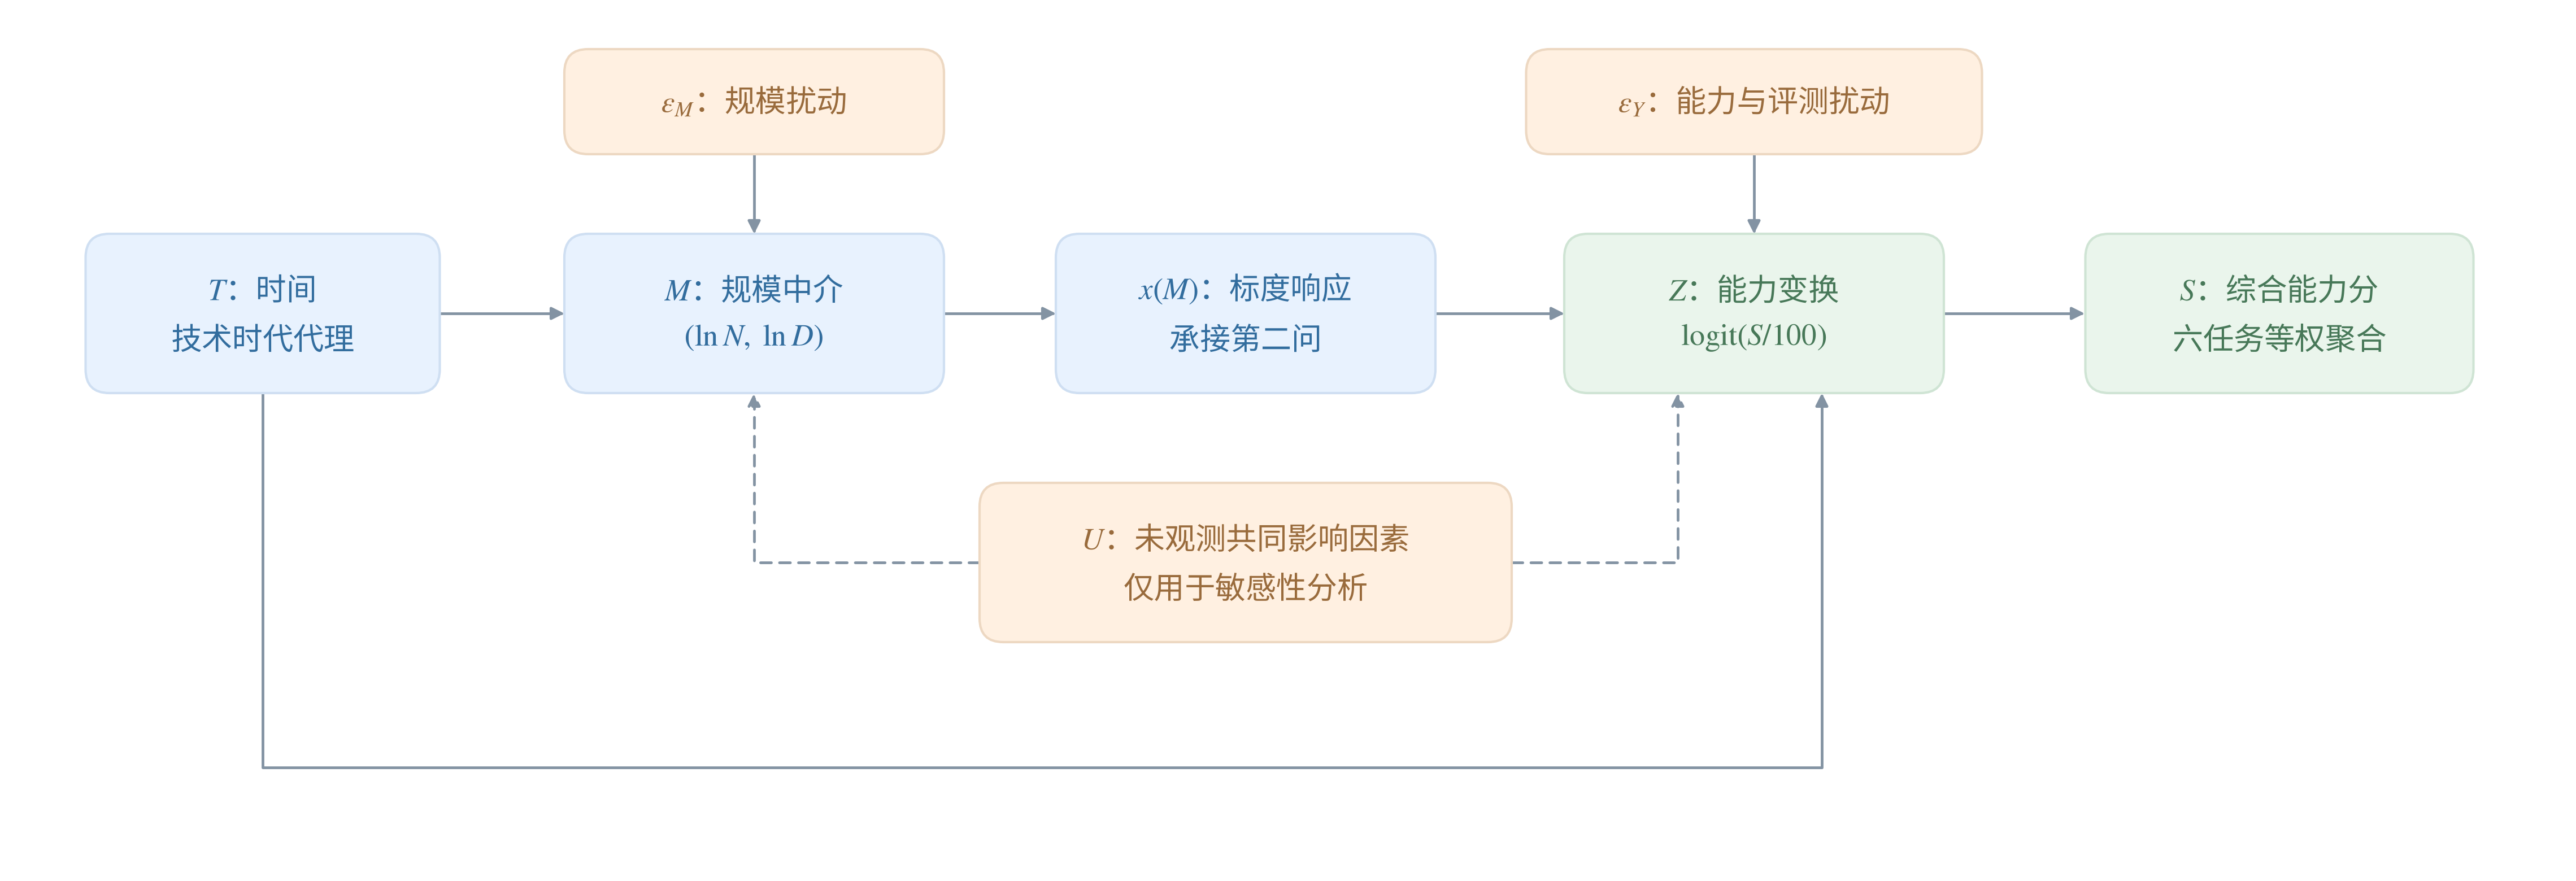

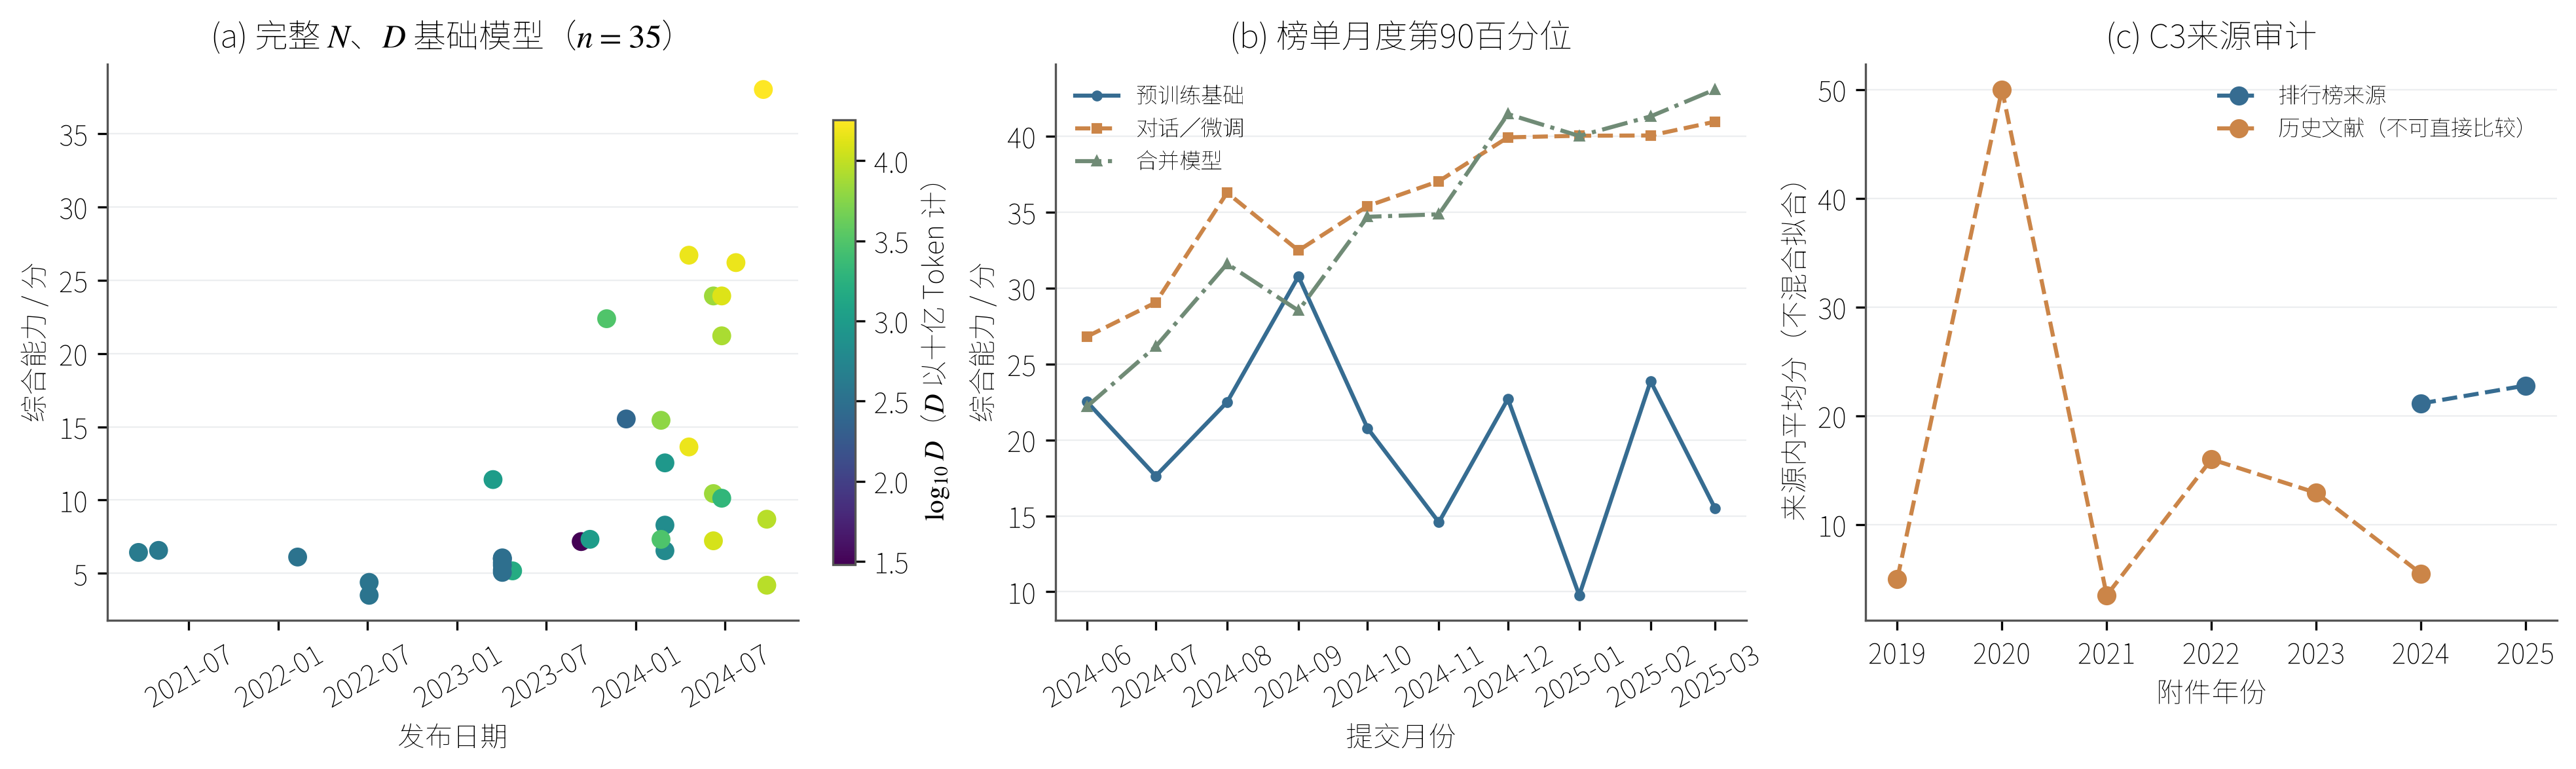

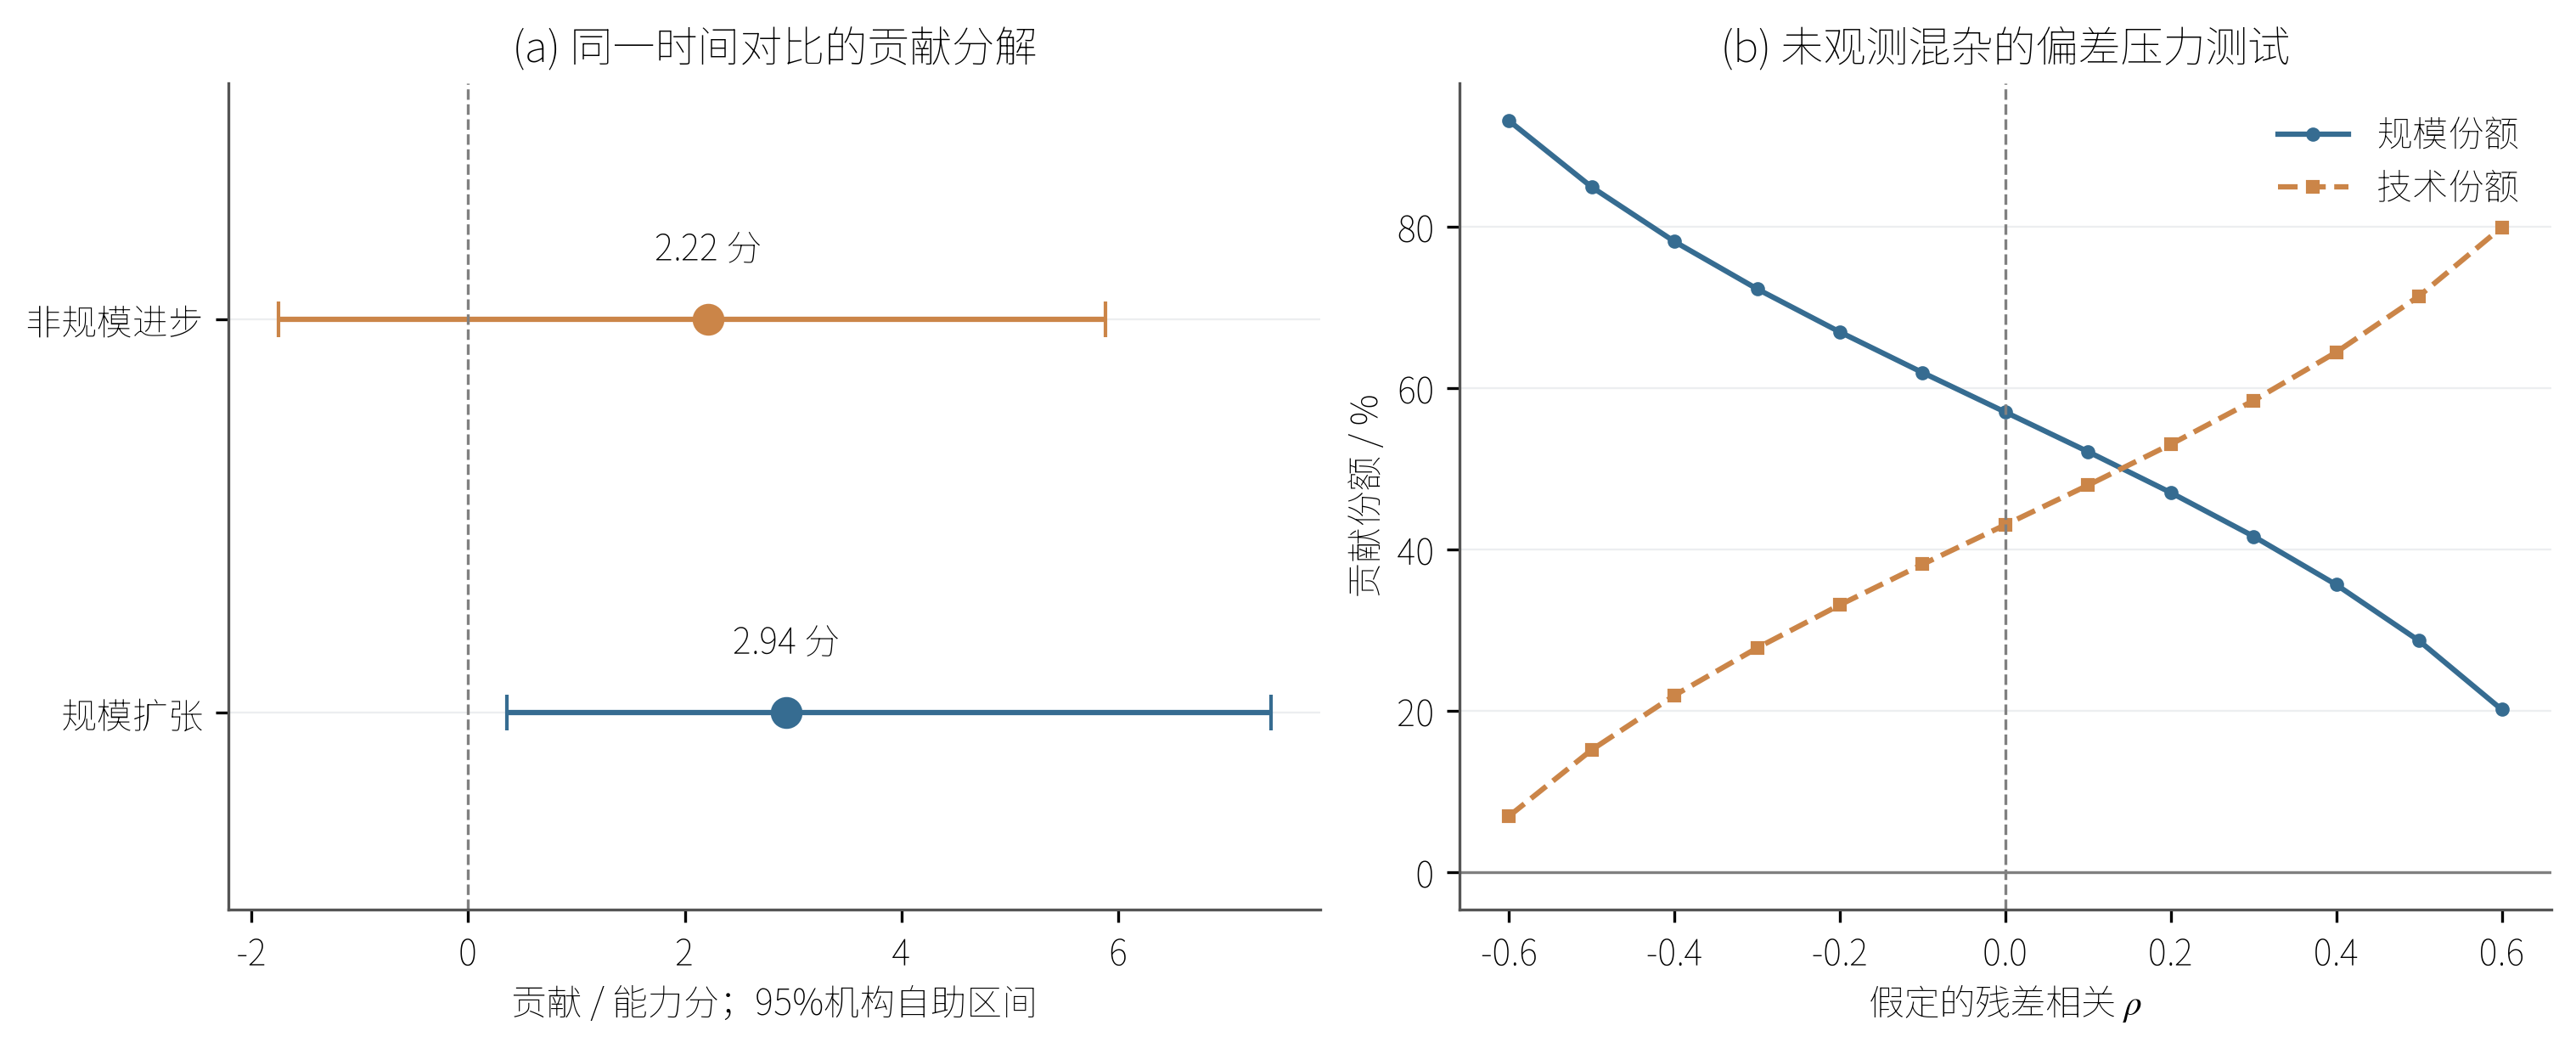

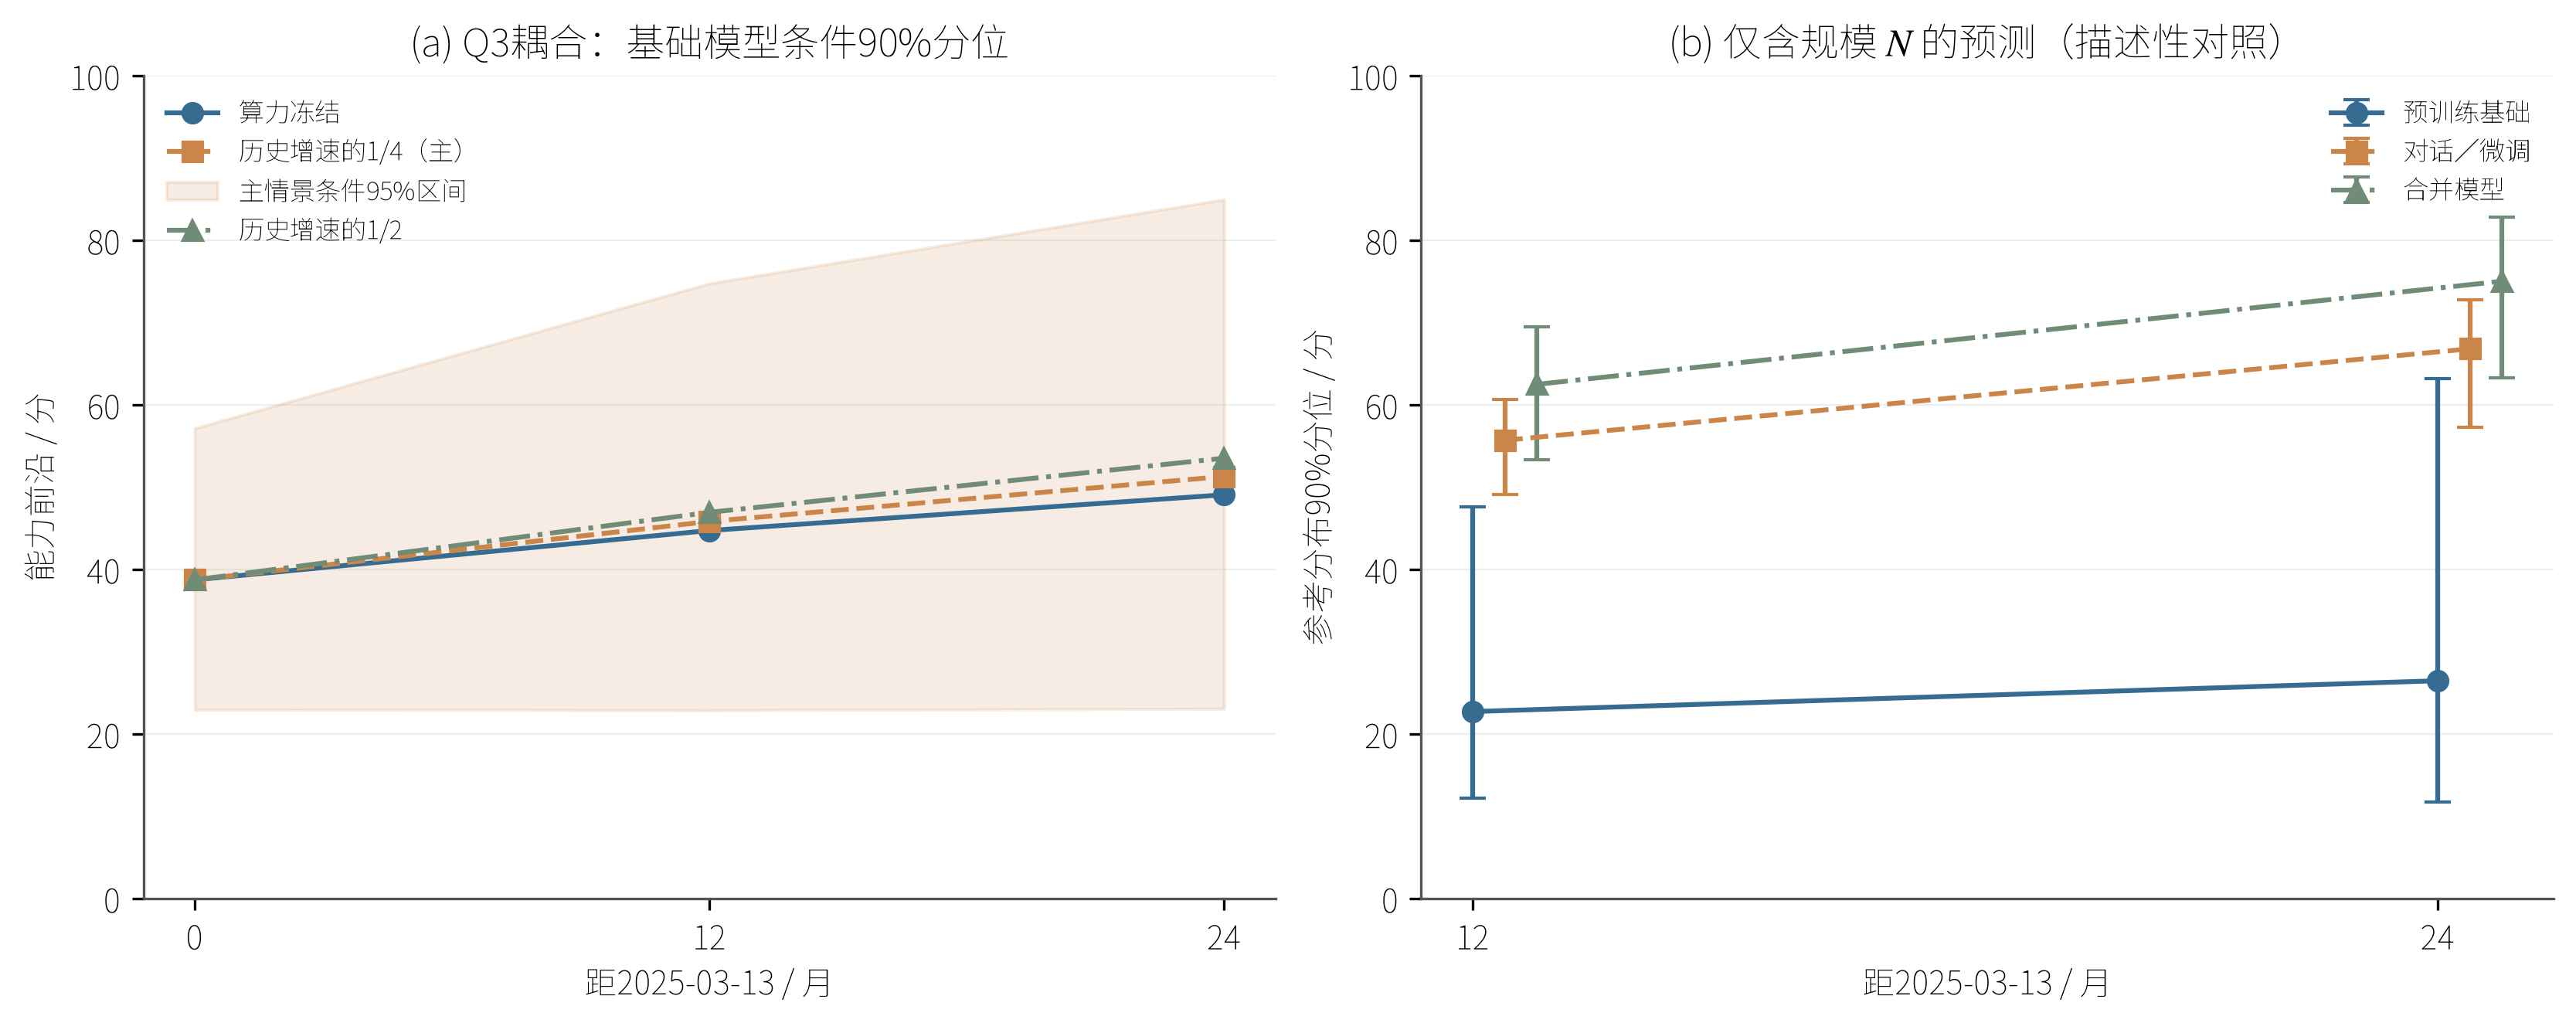

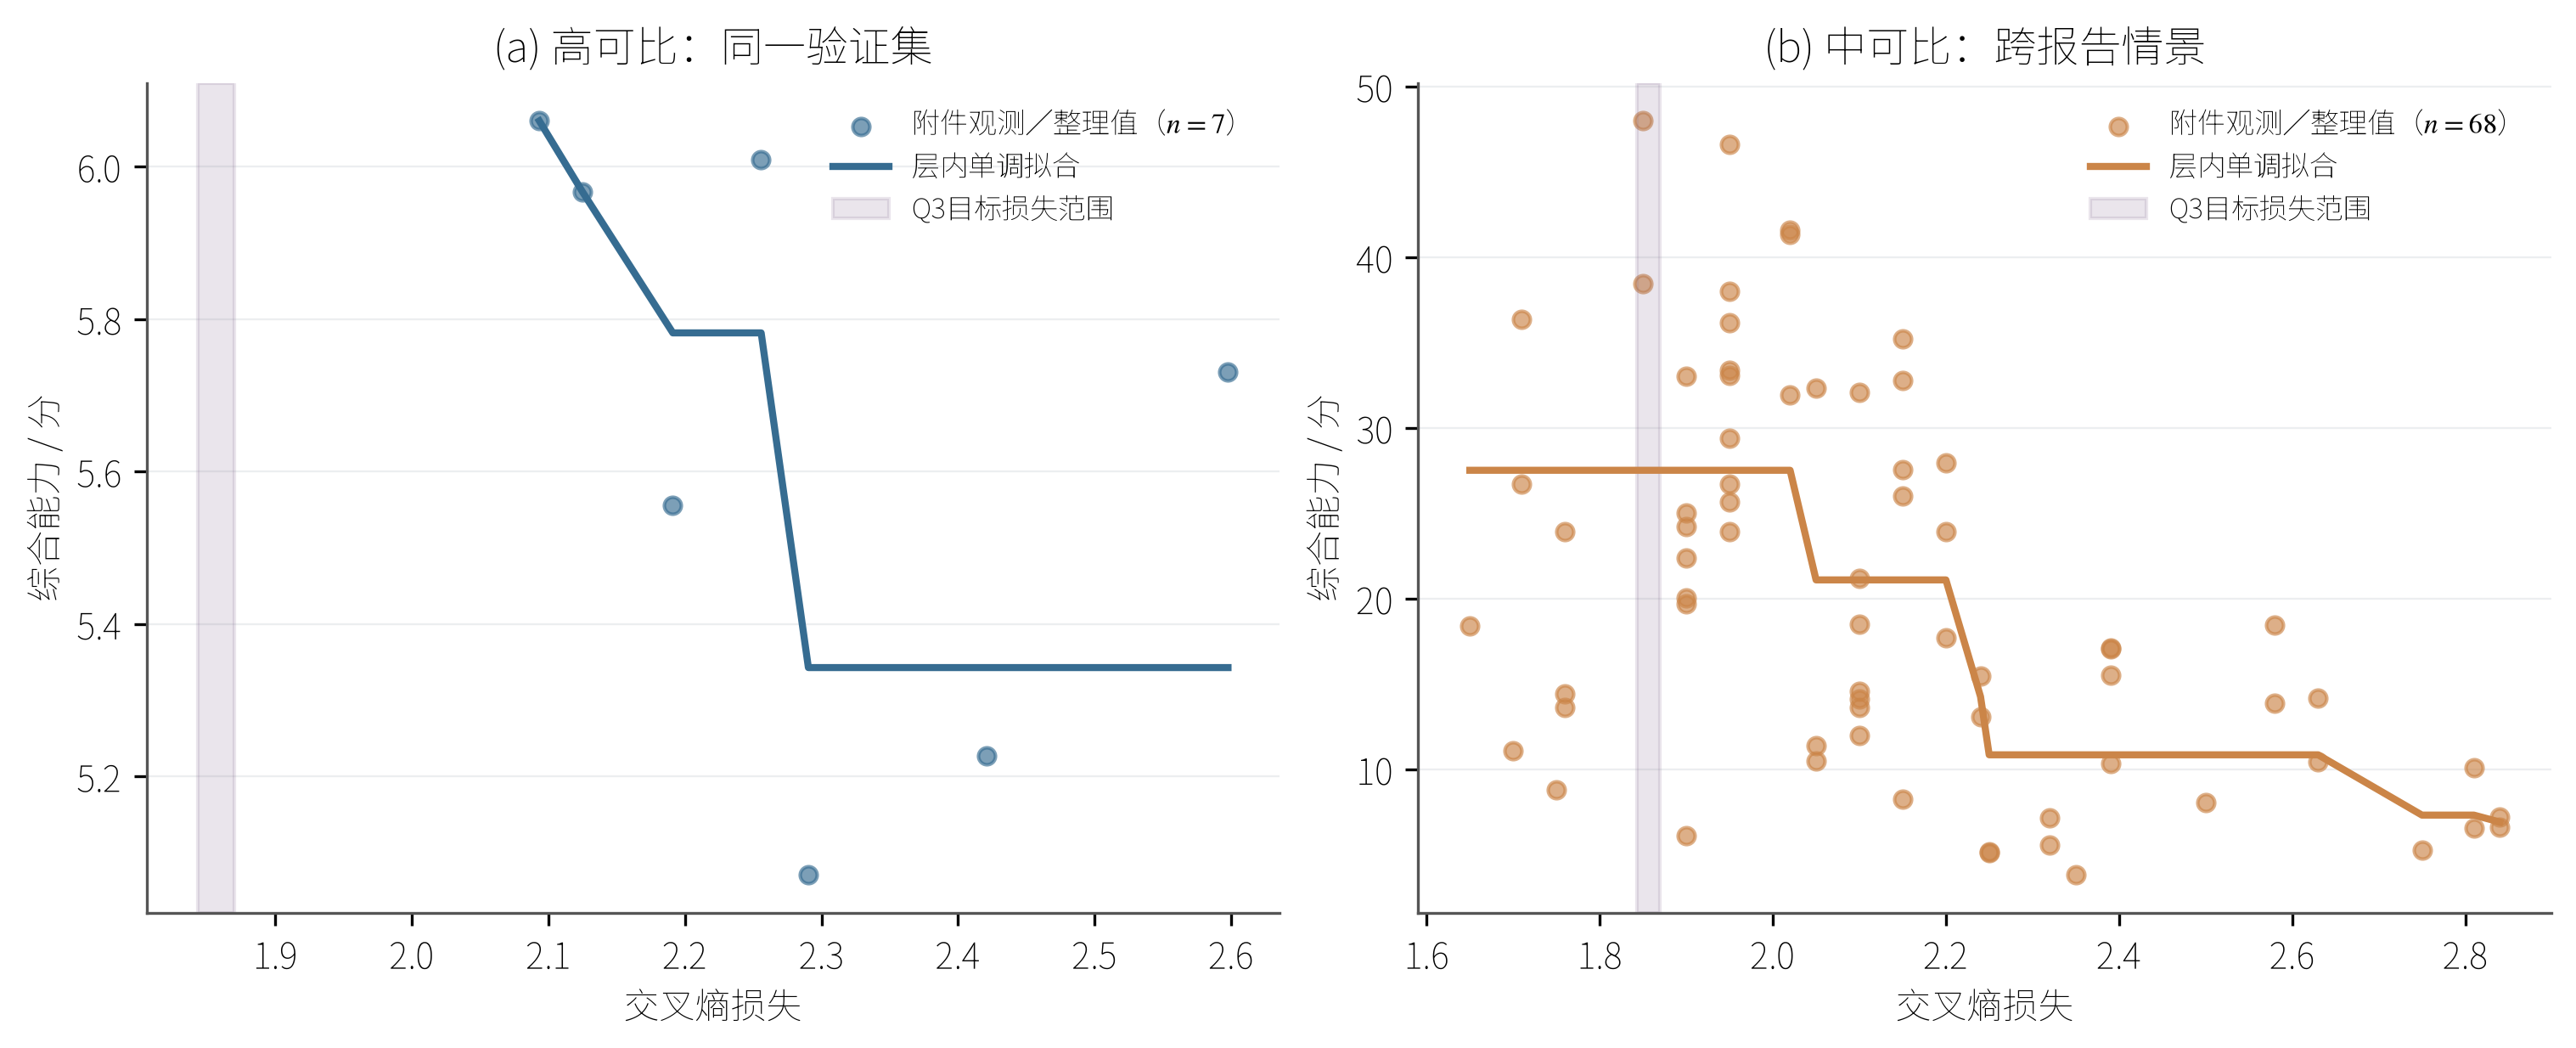

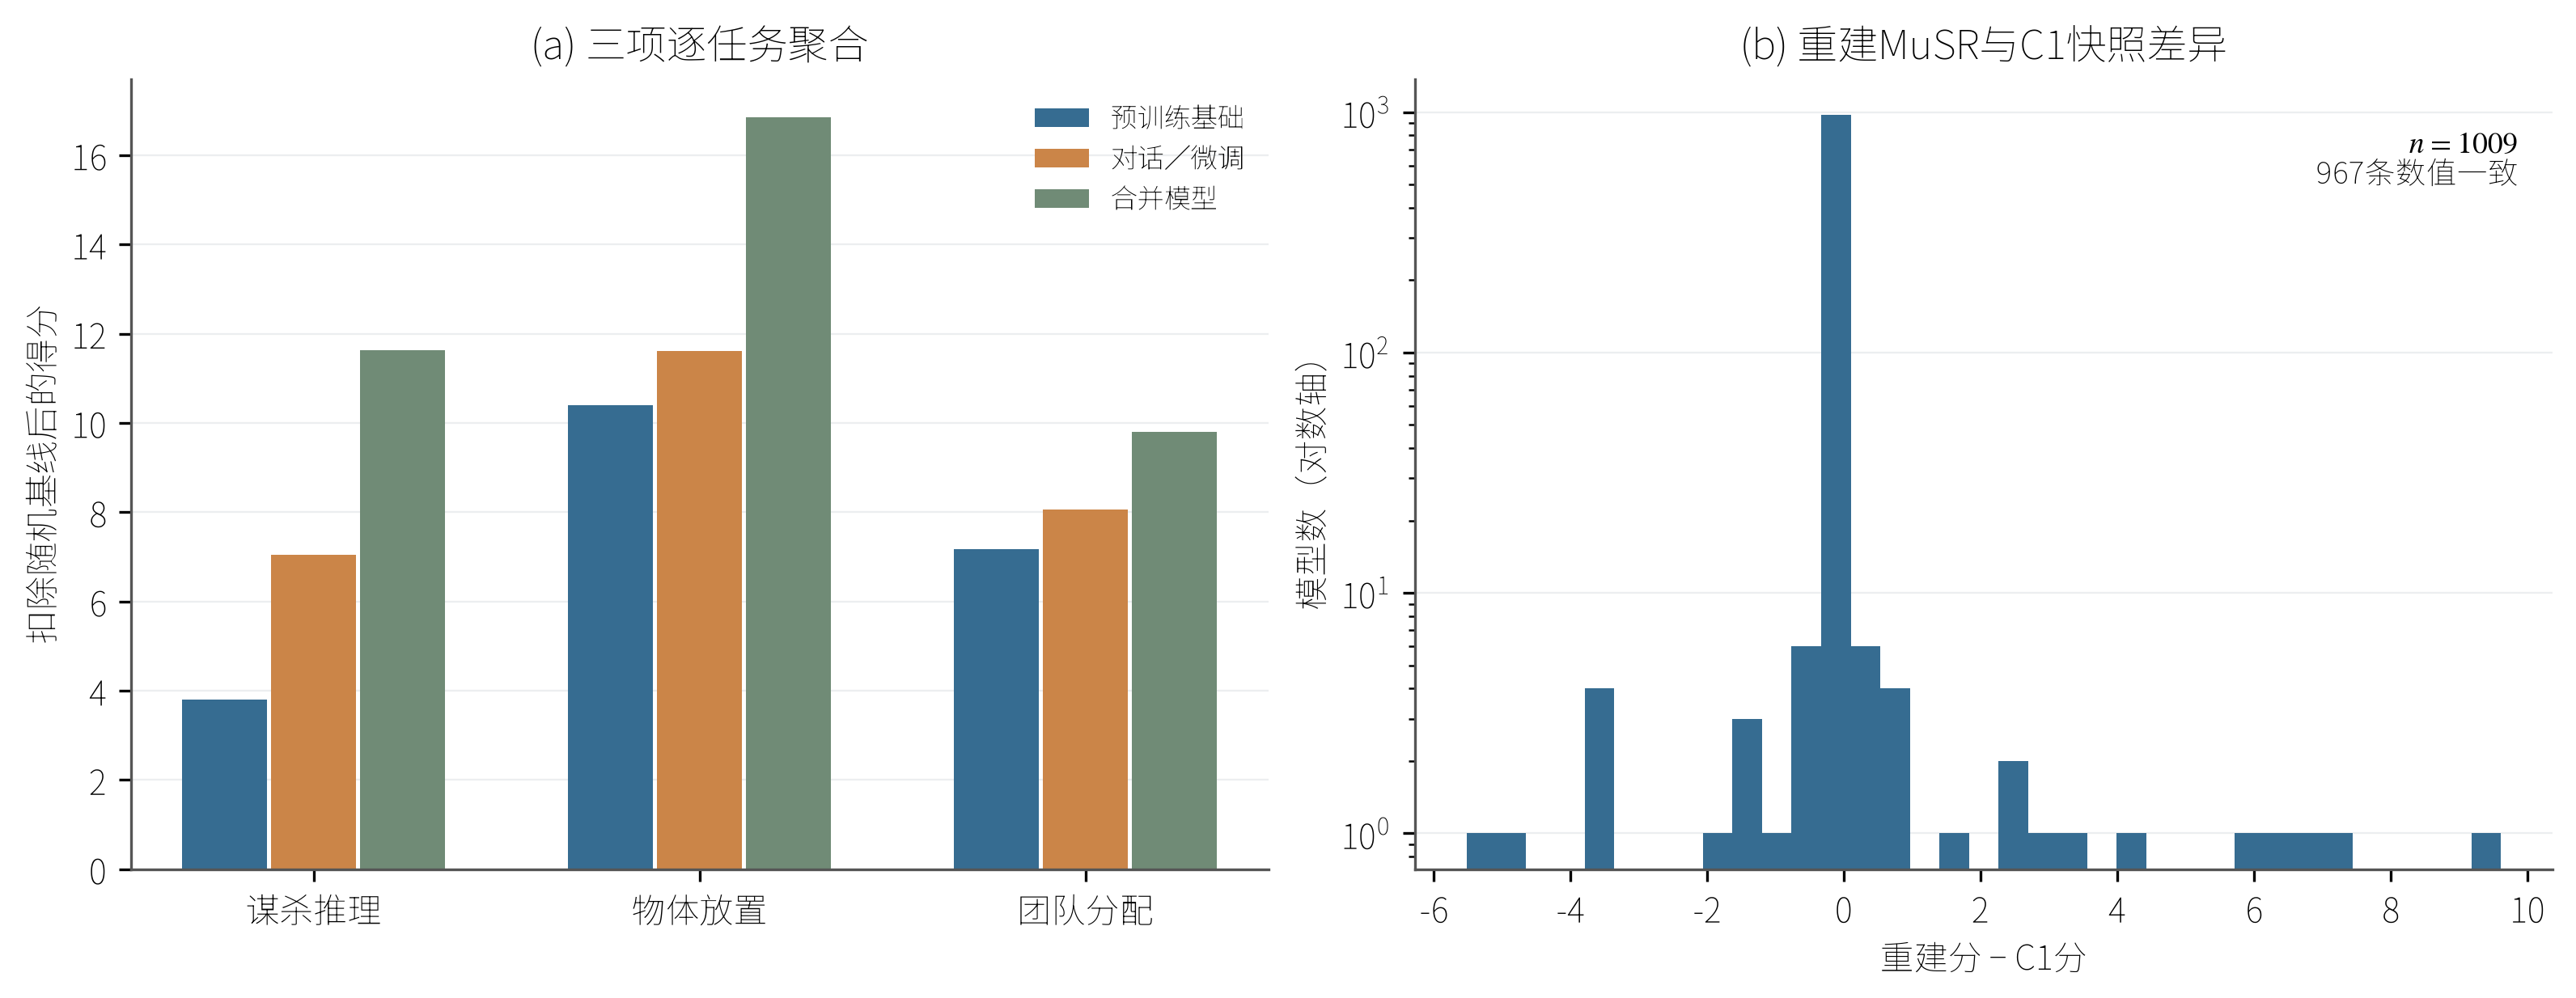

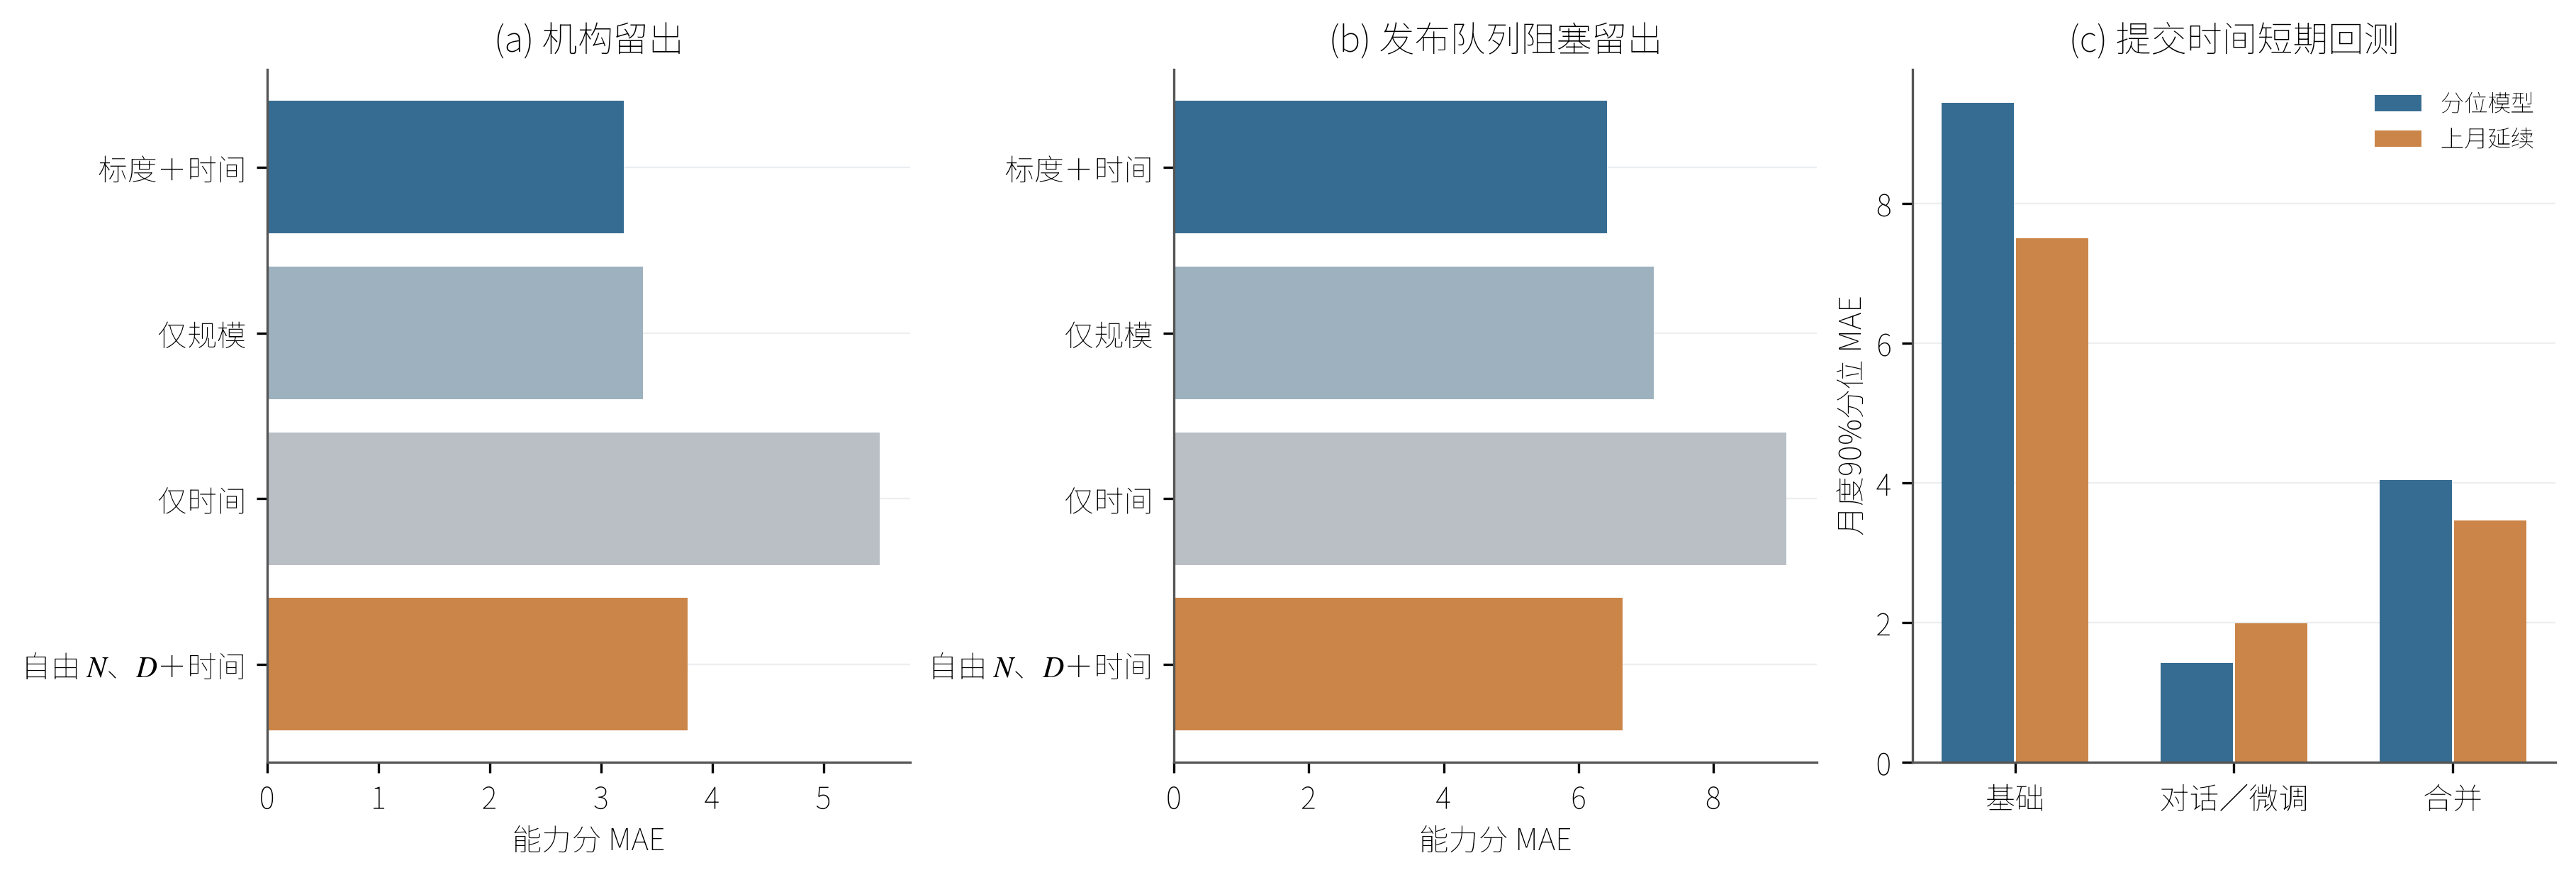

In [10]:
for name in ['01_causal_structure','02_data_and_evolution','03_mediation_and_sensitivity','04_frontier_forecasts','05_loss_benchmark_bridge','06_task_level_audit','07_validation']:
    display(Image(filename=str(OUT/'figures'/f'{name}.png'),width=1000))

In [11]:
display(Markdown((OUT/'模型求解.md').read_text(encoding='utf-8')))
print('完成。结果入口：',OUT/'results_summary.md')

# 问题四模型求解与结果

## 4.9 数据进入模型后的实际范围

全部观测来自本地附件；未下载外部模型记录。C1原有4576行，经许可证、日期、正参数量、六任务完整性筛选并去除57条重复仓库记录，保留2449个模型。提交时间为2024-06-08至2025-03-13，不足一年。模型类型计数为：{'chat_finetuned': 1542, 'merge': 667, 'pretrained': 192, 'continued': 43, 'other': 5}。合并模型单列，不能当作从头训练的新增资源样本。

C1与C4确定性匹配通过69个模型，其中满足基础模型、非明显MoE、发布日期和训练N/D均可用的主样本为35个、10个发布机构，发布日期覆盖2021-03-21至2024-09-24。历史贡献是这个可比子样本的条件归因，不能直接推成全部开源大模型产业的总体份额。N/D源于报告元数据，部分本身是估计值。

六任务重建均分与C1官方Average的最大绝对差为1.42e-14分，主分析等权口径与原榜单一致。C3共4599行，其中排行榜来源4573行，历史文献来源26行；历史来源只用于来源分层描述，不与同口径排行榜混合回归。图02展示两个时间轴与C3来源差别。

<span style="color:red">Insert figure here: figures/02_data_and_evolution.png</span>

## 4.10 JSON截断处理与逐任务结果

实际扫描1863个目录、1958个JSON，发现4个解析损坏文件。原件完整保留。1个损坏目录可使用同目录的有效替代评测，3个目录没有可解析评测，仅退出逐任务分析。最终保留1860个可解析模型，其中1856个具有MuSR三个叶子任务完整值；这不表示六大任务全部完整。

选中评测中1012个模型与筛选后C1匹配，其中967个MuSR重建分与C1在1e-6内一致，中位绝对差为0.000000分。差异记录保留在`c8_musr_reconstruction.csv`；最新评测与C1快照可能不同，不通过改写C1消除差异。三个叶子任务的分类型均分见`c8_task_type_summary.csv`与图06。

损坏文件名为：results_2025-02-13T18-27-04.338360.json、results_2025-02-13T18-27-04.338360.json、results_2025-02-13T18-27-04.338360.json、results_2025-02-13T18-27-04.338360.json。完整相对路径、解析错误、替代文件及无有效记录目录分别见`c8_corrupt_files.csv`和`c8_directory_ledger.csv`。处理规则与得分高低无关，未进行截断后拼接或缺项填零。

<span style="color:red">Insert figure here: figures/06_task_level_audit.png</span>

## 4.11 中介估计与贡献占比

主模型在logit能力尺度的估计为
$$
\widehat Z=-3.541544+1.217559x(N,D)+0.191554T.
$$
完整系数和噪声协方差分别保存于`mediation_coefficients.csv`、`noise_model.json`。时间T的单位为年，零点为2023-01-01；规模项x使用问题二固定参数。能力残差和成对规模残差均来自实际拟合，没有对原始数据额外添加随机噪声。

选取主样本发布日期四分位对比，即2023-04-03至2024-06-07。反事实积分得到起点能力9.115分、终点14.273分，总增量5.159分。这些是同一残差分布下的模型反事实均值，不是两个自然年度榜单的直接观测均分。

| 模型 | 规模贡献/分 | 技术贡献/分 | 总变化/分 | 规模份额 | 技术份额 |
| --- | --- | --- | --- | --- | --- |
| scale_time | 2.939 | 2.219 | 5.159 | 0.570 | 0.430 |
| free_nd | 2.249 | 2.812 | 5.061 | 0.444 | 0.556 |

主模型规模份额为56.98%，非规模份额为43.02%。按发布机构进行400次重抽样，规模贡献95%区间为[0.359, 7.412]分，非规模贡献为[-1.754, 5.887]分。相应份额区间分别为[10.50%, 123.91%]与[-23.91%, 89.50%]，没有裁成0—100%。非规模贡献区间包含零，说明样本不足以精确确定它的符号与比例；用户确认的解释假设并不能消除估计不确定性。

自由N/D系数对照给出的规模份额为44.44%，表明标度响应形状会影响归因。在ρ从−0.6到0.6的偏差压力测试中，规模份额范围为20.12%至93.09%；该范围不是真实混杂强度的置信区间。D测量误差压力测试见`data_volume_sensitivity.csv`。图01明确因果假设，图03展示贡献与敏感性。

<span style="color:red">Insert figure here: figures/01_causal_structure.png</span>

<span style="color:red">Insert figure here: figures/03_mediation_and_sensitivity.png</span>

## 4.12 泛化与前沿口径验证

均值能力预测采用相同划分、相同分数尺度评价，结果如下。发布队列留出存在同一模型在不同截点重复出现的情况，表中n是预测记录数，不是独立实验数；机构留出按整组划分。

| design | method | n | MAE | RMSE | bias |
| --- | --- | --- | --- | --- | --- |
| leave_organization | free_nd | 35 | 3.776 | 5.139 | -0.379 |
| leave_organization | scale_only | 35 | 3.375 | 4.817 | -0.228 |
| leave_organization | scale_time | 35 | 3.205 | 4.646 | -0.319 |
| leave_organization | time_only | 35 | 5.506 | 7.158 | -0.617 |
| publication_holdout | free_nd | 54 | 6.657 | 9.136 | -4.779 |
| publication_holdout | scale_only | 54 | 7.114 | 9.845 | -6.300 |
| publication_holdout | scale_time | 54 | 6.426 | 8.810 | -4.387 |
| publication_holdout | time_only | 54 | 9.088 | 12.075 | -7.184 |

条件90%分位的验证另列，不用均值模型RMSE代替：

| design | n | coverage | pinball_logit |
| --- | --- | --- | --- |
| leave_organization | 35 | 0.829 | 0.117 |
| publication_holdout | 54 | 0.704 | 0.149 |

名义90%分位的机构留出覆盖率为82.86%，发布队列留出覆盖率为70.37%，均低于90%。因此该前沿在样本外存在标定不足，不能把拟合分位数当作具有90%实证保障的未来上界。这里保留原始验证结果，不用留出集反向调高截距。

大样本提交日期回测只覆盖未来1—3个月，对照目标是同类型当月能力90%分位。预测时先将条件响应与规模分布、残差分布组合，再取整体90%分位。

| type | method | n | MAE | RMSE |
| --- | --- | --- | --- | --- |
| chat_finetuned | last_month_q90 | 11 | 1.990 | 2.575 |
| chat_finetuned | quantile_N_time | 11 | 1.419 | 1.710 |
| merge | last_month_q90 | 11 | 3.457 | 4.282 |
| merge | quantile_N_time | 11 | 4.041 | 4.532 |
| pretrained | last_month_q90 | 11 | 7.498 | 8.479 |
| pretrained | quantile_N_time | 11 | 9.443 | 12.424 |

按MAE比较，分位模型优于上月延续的类型为：对话／微调；未胜出的类型为：合并、基础。因此对话／微调趋势可以作为有短期比较依据的描述性前沿；基础和合并类型的趋势预测仅作敏感性对照，不声称优于简单延续。短期回测不能为12/24个月外推提供同等强度的验证。主结构模型的长期情景也没有被这些短期榜单结果“证实”。

<span style="color:red">Insert figure here: figures/07_validation.png</span>

## 4.13 Loss—Benchmark桥接及误差传播

桥接逐层留一结果如下。n为该层总记录，validated_n为测试Loss仍位于训练折支撑区间内的记录；端点出界不参与误差平均，不能只报误差而隐藏覆盖。

| tier | n | validated_n | MAE | RMSE |
| --- | --- | --- | --- | --- |
| high | 7 | 5 | 0.370 | 0.444 |
| medium | 68 | 67 | 7.276 | 9.039 |

中可比层还按报告来源整组留出，共得到68条预测记录，其中66条处于训练支撑范围。可换算记录MAE为7.365分。相同报告的多个模型并不是多次独立标度实验。

Q3未来主配置Loss范围为[1.843212, 1.869591]。高可比层是否支持目标Loss，应逐行看`q3_absolute_bridge_forecast.csv`；当前高可比层支持0个目标配置。中可比桥接仅作为跨报告情景，并传播报告重抽样的不确定性。该桥接输出没有再加一次时间进步项，避免重复计量。高可比的局部小误差不代表其能外推到低Loss、高能力区域。

| horizon_months | tier | loss | prediction | lo | hi | supported | bootstrap_supported |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 12 | high | 1.863 | — | — | — | False | 0 |
| 12 | medium | 1.863 | 27.514 | 20.211 | 34.987 | True | 400 |
| 24 | high | 1.856 | — | — | — | False | 0 |
| 24 | medium | 1.856 | 27.514 | 20.564 | 34.348 | True | 400 |

<span style="color:red">Insert figure here: figures/05_loss_benchmark_bridge.png</span>

## 4.14 未来12/24个月的条件前沿

预测起点固定为2025-03-13，是附件中最后可比观测日，不是程序运行日。故12个月、24个月的目标分别为2026-03-13和2027-03-13；这些输出不能表述为从2026年9月起的实时预测。C4历史算力样本为215个模型，最近一年预算90%分位为3.303422e+24 FLOPs，季度前沿拟合的年对数增速为1.033713。

主放缓情景取历史对数增速的四分之一，技术趋势半衰期24个月。在问题三p0、50%参考质量切片、s_Q=1、4096上下文、指数成本下得到：

| 目标日 | 预算/FLOPs | N/十亿 | D/十亿Token | Loss | 条件前沿/分 | 区间下限 | 区间上限 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 2026-03-13 | 4.2776e+24 | 75.102 | 8350.038 | 1.863 | 45.826 | 22.886 | 74.761 |
| 2027-03-13 | 5.5390e+24 | 84.394 | 9622.229 | 1.856 | 51.295 | 23.055 | 84.972 |

这些是基础模型在资源最优路径上的条件90%分位前沿。主样本最新发布日期早于预测起点，模型在起点就已有约0.465年的时间外推；未来参数量超出主样本范围时，`N_extrapolated`逐行标识。质量上限是问题三的文档筛选参照，不能解释为已证实的Token供给保证。

区间包含发布机构层面的能力拟合及算力元数据重抽样不确定性，但条件于问题二参数、非规模解释和结构迁移。不同成本／质量场景共45个资源配置，另有冻结、半增速和技术半衰期敏感性，分别见`q3_cost_quality_sensitivity.csv`及`coupled_frontier_forecast.csv`；它们不是已发生的真实实验。

大样本描述性前沿如下，训练数据量D缺失，时间项不能用于非规模贡献归因。表内参考规模分布固定为最近三个月，并按算力情景平移。

| 类型 | 预测月数 | 描述性前沿/分 | 区间下限 | 区间上限 |
| --- | --- | --- | --- | --- |
| 基础 | 12 | 22.717 | 12.164 | 47.594 |
| 基础 | 24 | 26.463 | 11.696 | 63.205 |
| 对话／微调 | 12 | 55.692 | 49.117 | 60.675 |
| 对话／微调 | 24 | 66.810 | 57.309 | 72.754 |
| 合并 | 12 | 62.493 | 53.337 | 69.484 |
| 合并 | 24 | 75.024 | 63.316 | 82.797 |

当前短期验证支持对话／微调类型优于朴素基线；合并类型虽可能给出更高预测值，但短期预测未胜出，不据其较高数值宣称整体最优前沿。删除单个能力任务的12个月预测范围为：{'chat_finetuned': {'min': 48.33653287539891, 'max': 61.47666751345573}, 'pretrained': {'min': 14.898484387378677, 'max': 30.031651449502505}}。任务权重影响实质性能力定义，不能通过挑选任务得到预期排名。

<span style="color:red">Insert figure here: figures/04_frontier_forecasts.png</span>

## 4.15 可以成立的结论与尚未识别的部分

本次完整实现了“附件审计→N/D中介分解→Loss桥接→Q3资源耦合→12/24个月前沿与不确定性”的计算链。主样本的点估计支持规模和非规模两条路径均有正贡献，但技术贡献区间包含零，且份额对结构形状和混杂压力测试敏感。扩大模型并非唯一解释，现有数据也不足以确定一个精确、普适的技术贡献百分比。

高可比Loss桥接不能覆盖本次未来资源配置的低Loss区间，中可比映射又存在明显跨报告误差。因此条件结构前沿、描述性聊天前沿及绝对桥接情景并列报告，不合并成一条看似精确的预测线。数据质量刻度、未知训练Token供给、跨族标度迁移、元数据缺失选择与远期技术速率仍是模型边界。

独立数值和证据核验状态：passed，通过24项。验证涵盖公式恒等式、退化情形、有限差分、预算守恒、支撑边界、任务重建及输入哈希；它不构成因果识别证明。结果表是论文数字的唯一来源，原始附件未修改。


完成。结果入口： /Users/luochen/华为杯/F题/z备份_副本/output_q4_evolution/results_summary.md
